In [48]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [49]:
from sklearn.model_selection import train_test_split, cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

In [51]:
train_df

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


In [52]:
train_df.drop('id', axis=1,  inplace=True)
test_df.drop('id', axis=1,  inplace=True)

In [53]:
print(train_df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [54]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [55]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


In [56]:
print(test_df.shape)

(254655, 19)


In [57]:
print(train_df['Churn'].value_counts())
print(train_df['Churn'].value_counts(normalize=True)*100)

Churn
No     460377
Yes    133817
Name: count, dtype: int64
Churn
No     77.479241
Yes    22.520759
Name: proportion, dtype: float64


In [58]:
numeric_cols = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

train_df.groupby('Churn')[numeric_cols].mean()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Churn,,,,
No,0.073588,42.231313,61.293633,2771.500515
Yes,0.253488,17.125343,81.597525,1540.976020


In [59]:
categorical_cols = train_df.select_dtypes(include='object').columns.drop('Churn')

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(
        train_df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean())
        .sort_values(ascending=False)
    ) 


--- gender ---
gender
Female    0.228036
Male      0.222348
Name: Churn, dtype: float64

--- Partner ---
Partner
No     0.324621
Yes    0.133796
Name: Churn, dtype: float64

--- Dependents ---
Dependents
No     0.291354
Yes    0.072796
Name: Churn, dtype: float64

--- PhoneService ---
PhoneService
Yes    0.22892
No     0.16815
Name: Churn, dtype: float64

--- MultipleLines ---
MultipleLines
Yes                 0.277026
No                  0.182322
No phone service    0.168150
Name: Churn, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.415366
DSL            0.103064
No             0.014311
Name: Churn, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.406133
Yes                    0.086821
No internet service    0.014311
Name: Churn, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     0.391026
Yes                    0.167240
No internet service    0.014311
Name: Churn, dtype: float64

--- DeviceProtection ---
D

In [60]:
X = train_df.drop('Churn', axis=1)
y = train_df['Churn']

In [61]:
y = y.map({
    'No': 0,
    'Yes': 1
})

In [62]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(594194, 19)
(594194,)
Churn
0    460377
1    133817
Name: count, dtype: int64


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [64]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_test.value_counts(normalize=True))

Train:
Churn
0    0.774791
1    0.225209
Name: proportion, dtype: float64

Validation:
Churn
0    0.774796
1    0.225204
Name: proportion, dtype: float64


In [65]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = X_train.select_dtypes(include=['object']).columns

print("Numeric:", list(numeric_cols))
print("Categorical:", list(categorical_cols))

Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

In [67]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Before encoding:")
print(X_train.shape)
print(X_test.shape)

print("\nAfter encoding:")
print(X_train_encoded.shape)
print(X_test_encoded.shape)

Before encoding:
(475355, 19)
(118839, 19)

After encoding:
(475355, 45)
(118839, 45)


In [68]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=100
)

model.fit(X_train_encoded, y_train)
y_pred = model.predict(X_test_encoded)

In [69]:
from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        confusion_matrix
)


print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, model.predict_proba(X_test_encoded)[:, 1]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8544164794385681
Precision: 0.6836710924761239
Recall   : 0.6579979822889811
F1 Score : 0.6705889072942252
ROC-AUC  : 0.9084281629154494

Confusion Matrix:
[[83928  8148]
 [ 9153 17610]]


# Target Balance karke

In [70]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_balanced.fit(X_train_encoded, y_train)
y_pred_balanced = model_balanced.predict(X_test_encoded)

In [71]:
from sklearn.metrics import (
      accuracy_score,
      precision_score,
      recall_score,
      f1_score,
      roc_auc_score,
      confusion_matrix
)


print("Accuracy :", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall   :", recall_score(y_test, y_pred_balanced))
print("F1 Score :", f1_score(y_test, y_pred_balanced))


y_prob_balanced = model_balanced.predict_proba(X_test_encoded)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy : 0.806216814345459
Precision: 0.5430323145715208
Recall   : 0.8803198445615215
F1 Score : 0.6717130678983307
ROC-AUC: 0.9082803763850632

Confusion matrix:
[[72250 19826]
 [ 3203 23560]]


In [72]:
#Threshold Tuning

from sklearn.metrics import precision_score, recall_score, f1_score

y_prob = model.predict_proba(X_test_encoded)[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.2 | Precision: 0.5317 | Recall: 0.8936 | F1: 0.6667
Threshold: 0.3 | Precision: 0.5833 | Recall: 0.8314 | F1: 0.6856
Threshold: 0.4 | Precision: 0.6309 | Recall: 0.7572 | F1: 0.6883
Threshold: 0.5 | Precision: 0.6837 | Recall: 0.6580 | F1: 0.6706
Threshold: 0.6 | Precision: 0.7425 | Recall: 0.5210 | F1: 0.6123
Threshold: 0.7 | Precision: 0.8186 | Recall: 0.3300 | F1: 0.4704


In [73]:
threshold_results = []

for threshold in np.arange(0.01, 1.00, 0.01):

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(
    threshold_df.loc[
        threshold_df['f1'].idxmax()
    ]
)

threshold    0.340000
precision    0.603478
recall       0.803871
f1           0.689408
Name: 33, dtype: float64


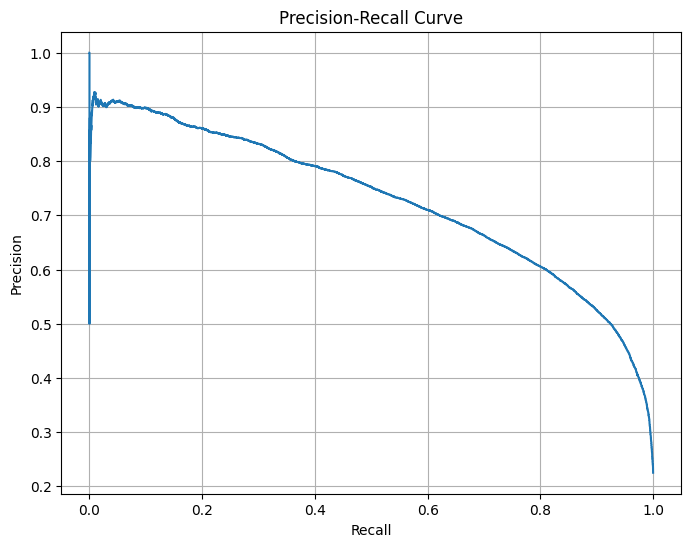

In [74]:
# Precision-Recall Curve

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid()
plt.show()

Best Threshold: 0.34
Best F1: 0.6894076554563953


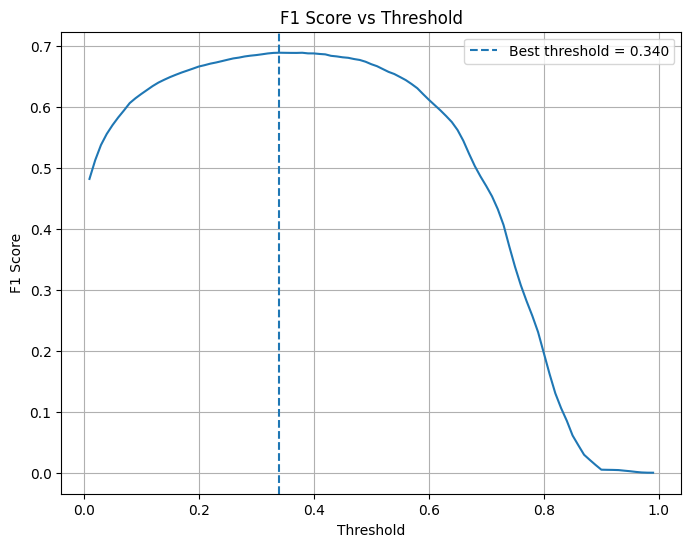

In [75]:
# F1 Score

import numpy as np
import matplotlib.pyplot as plt

f1_scores = threshold_df['f1'].values

best_idx = np.argmax(f1_scores)

best_threshold = threshold_df['threshold'].iloc[best_idx]
best_f1 = f1_scores[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

plt.figure(figsize=(8, 6))

plt.plot(threshold_df['threshold'], f1_scores)

plt.axvline(
    best_threshold,
    linestyle='--',
    label=f'Best threshold = {best_threshold:.3f}'
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.legend()
plt.grid()
plt.show()

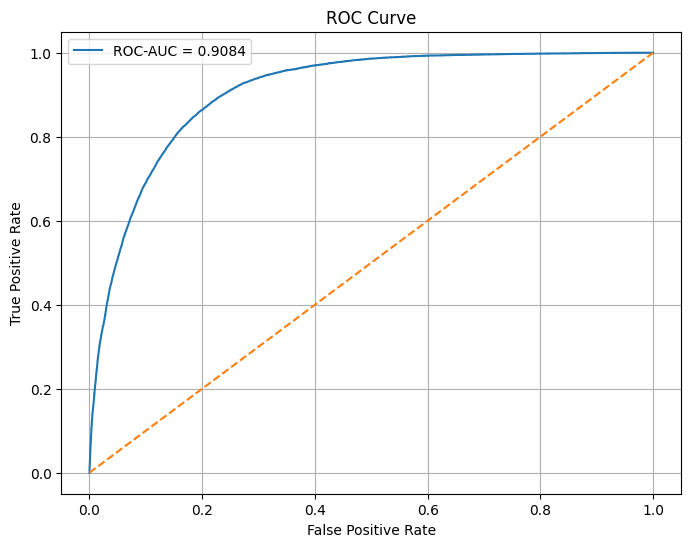

In [76]:
# ROC Curve


from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [77]:
from sklearn.tree import DecisionTreeClassifier


dt_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

dt_model.fit(X_train_encoded, y_train)
y_test_prob_dt = dt_model.predict_proba(X_test_encoded)[:, 1]

dt_auc = roc_auc_score(
    y_test,
    y_test_prob_dt
)

print("Decision Tree ROC-AUC:", dt_auc)

Decision Tree ROC-AUC: 0.909405379332637


In [78]:
# Decision Tree Parameters-Tuning
depths = [8, 9, 10, 11, 12]

dt_results = []

for depth in depths:

    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt_model.fit(X_train_encoded, y_train)

    y_test_prob_dt = dt_model.predict_proba(
        X_test_encoded
    )[:, 1]

    dt_auc = roc_auc_score(
        y_test,
        y_test_prob_dt
    )
    dt_results.append(
        {
            "max_depth": depth,
            "ROC-AUC": dt_auc
        }
    )
dt_results_df = pd.DataFrame(dt_results)
print(dt_results_df)

   max_depth   ROC-AUC
0          8  0.909405
1          9  0.910014
2         10  0.909436
3         11  0.907269
4         12  0.903069


In [79]:
from sklearn.ensemble import RandomForestClassifier

depths = [5, 7, 9, 11, 13, 15]

rf_results = []

for depth in depths:
    rf_model = RandomForestClassifier(
        n_estimators=150,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_encoded, y_train)
    
    y_test_prob_rf = rf_model.predict_proba(X_test_encoded)[:, 1]
    
    rf_auc = roc_auc_score(
        y_test,
        y_test_prob_rf
    )
    
    rf_results.append({
        'max_depth': depth,
        'ROC-AUC': rf_auc
    })

rf_results_df = pd.DataFrame(rf_results)

print(rf_results_df)

   max_depth   ROC-AUC
0          5  0.905878
1          7  0.909185
2          9  0.911160
3         11  0.912363
4         13  0.912716
5         15  0.911940


In [80]:
from sklearn.ensemble import HistGradientBoostingClassifier

iterations = [250, 300]

hgb_results = []

for n in iterations:
    hgb_model = HistGradientBoostingClassifier(
        max_iter=n,
        learning_rate=0.1,
        max_leaf_nodes=31,
        max_bins=255,
        min_samples_leaf=200,
        random_state=42
    )
    
    hgb_model.fit(X_train_encoded, y_train)
    
    y_test_prob_hgb = hgb_model.predict_proba(X_test_encoded)[:, 1]
    
    hgb_auc = roc_auc_score(
        y_test,
        y_test_prob_hgb
    )
    
    hgb_results.append({
        'max_iter': n,
        'ROC-AUC': hgb_auc
    })

hgb_results_df = pd.DataFrame(hgb_results)

print(hgb_results_df)

   max_iter   ROC-AUC
0       250  0.916274
1       300  0.916277


# Feature Engineering

In [81]:
X = train_df.drop('Churn', axis=1).copy()
y = train_df['Churn'].map({'No': 0, 'Yes': 1})

In [82]:
X['TenureMonthlyRatio'] = X['tenure'] / (X['MonthlyCharges'] + 1)

X['TotalChargesExpected'] = X['tenure'] * X['MonthlyCharges']

X['ChargeDifference'] = (
    X['TotalCharges'] - X['TotalChargesExpected']
)

In [83]:
X.drop(
    [
        'TenureMonthlyRatio',
        'TotalChargesExpected',
        'ChargeDifference'
    ],
    axis=1,
    inplace=True
)

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = X_train.select_dtypes(
    include=['object']
).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [85]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.1,
    max_leaf_nodes=31,
    max_bins=255,
    min_samples_leaf=200,
    random_state=42
)

hgb_model.fit(X_train_encoded, y_train)

y_test_prob_hgb = hgb_model.predict_proba(X_test_encoded)[:, 1]

hgb_auc = roc_auc_score(
    y_test,
    y_test_prob_hgb
)

print("New Feature HGB ROC-AUC:", hgb_auc)

New Feature HGB ROC-AUC: 0.9162769213893682


In [86]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0.5,
    reg_alpha=0,
    reg_lambda=1,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_encoded,
    y_train,
    eval_set=[(X_test_encoded, y_test)],
    verbose=False
)

y_test_prob_xgb = xgb_model.predict_proba(
    X_test_encoded
)[:, 1]

xgb_auc = roc_auc_score(
    y_test,
    y_test_prob_xgb
)

print("XGBoost ROC-AUC:", xgb_auc)
print("Best iteration:", xgb_model.best_iteration)
print("Best validation score:", xgb_model.best_score)

XGBoost ROC-AUC: 0.9168236800143996
Best iteration: 665
Best validation score: 0.9168236800143997


In [87]:
test_df['AvgMonthlySpend'] = test_df['TotalCharges'] / (test_df['tenure'] + 1)
test_df['MonthlyChargesSquared'] = test_df['MonthlyCharges'] ** 2
test_df['TenureSquared'] = test_df['tenure'] ** 2

test_df_encoded = preprocessor.transform(test_df)

print(test_df_encoded.shape)
test_prob = xgb_model.predict_proba(
    test_df_encoded
)[:, 1]


submission_test = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e3/test.csv"
)

submission = pd.DataFrame({
    'id': submission_test['id'],
    'Churn': test_prob
})

submission.head()

(254655, 45)


,id,Churn
0,594194,0.073793
1,594195,0.000387
2,594196,0.104452
3,594197,0.004313
4,594198,0.546889


In [88]:
submission.to_csv(
    '/kaggle/working/submission.csv',
    index=False
)

In [89]:
print(submission.shape)
print(submission.head(10))
print(submission['Churn'].describe())

(254655, 2)
       id     Churn
0  594194  0.073793
1  594195  0.000387
2  594196  0.104452
3  594197  0.004313
4  594198  0.546889
5  594199  0.169841
6  594200  0.914004
7  594201  0.002166
8  594202  0.041907
9  594203  0.300443
count    254655.000000
mean          0.218286
std           0.276328
min           0.000035
25%           0.005893
50%           0.064258
75%           0.391857
max           0.991060
Name: Churn, dtype: float64
